<a href="https://colab.research.google.com/github/sangramshitole07/APS/blob/main/APS_Binary_Classification_Tumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np


In [5]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

In [6]:
data =load_breast_cancer()
X=pd.DataFrame(data.data,columns=data.feature_names)
y=pd.Series((data.target==0).astype(int),
            name='malignant')
print(y.value_counts())
print("Feature matrix shape: ", X.shape)
print("Target Shape ", y.shape)
print("class Name : ", data.target_names)

malignant
0    357
1    212
Name: count, dtype: int64
Feature matrix shape:  (569, 30)
Target Shape  (569,)
class Name :  ['malignant' 'benign']


In [7]:
class_counts=y.value_counts().sort_index()
class_distribution =pd.DataFrame({
    'Class': data.target_names,
    'Count': class_counts.values,
    'Proportion': class_counts.values / len(y)
})
print(class_distribution)

       Class  Count  Proportion
0  malignant    357    0.627417
1     benign    212    0.372583


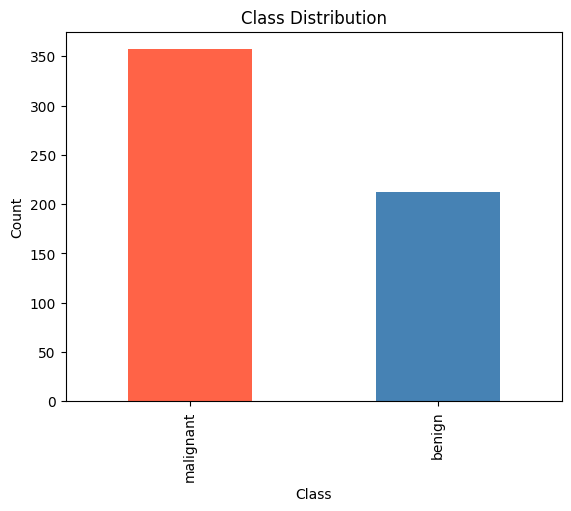

In [11]:
class_distribution.plot(
    x="Class",
    y="Count",
    kind="bar",
    legend=False,
    color=["tomato", "steelblue"]
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [15]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)
print(y_train.value_counts())
print(y_test.value_counts())
print("Train shape: ", X_train.shape)
print("Test shape: ", X_test.shape)
print("Trainig size: ", len(y_train))
print("Testing size: ", len(y_test))

#normalize


malignant
0    285
1    170
Name: count, dtype: int64
malignant
0    72
1    42
Name: count, dtype: int64
Train shape:  (455, 30)
Test shape:  (114, 30)
Trainig size:  455
Testing size:  114


In [16]:
model=make_pipeline(StandardScaler(),LogisticRegression(max_iter=1000))
model.fit(X_train,y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(max_iter=1000))])

In [20]:
probab=model.predict_proba(X_test)
print(probab[:5])

[[9.99635432e-01 3.64568116e-04]
 [1.07465986e-08 9.99999989e-01]
 [9.57432053e-01 4.25679471e-02]
 [4.23812678e-01 5.76187322e-01]
 [4.90844511e-01 5.09155489e-01]]


In [21]:
print(probab[:5].sum(axis=1))

[1. 1. 1. 1. 1.]


In [30]:
results=pd.DataFrame({
    "Actual_class: ": y_test.values,
    "P_malignant: ": probab[:,0],
    "P_benign: ": probab[:,1]
})
print(results.head(10))

   Actual_class:   P_malignant:   P_benign: 
0               0   9.996354e-01    0.000365
1               1   1.074660e-08    1.000000
2               0   9.574321e-01    0.042568
3               1   4.238127e-01    0.576187
4               0   4.908445e-01    0.509155
5               0   9.993840e-01    0.000616
6               1   2.384659e-01    0.761534
7               0   9.989878e-01    0.001012
8               0   9.994313e-01    0.000569
9               0   9.892324e-01    0.010768


In [35]:
#use a threshold to genearate prediction
threshold=0.50
results["Predicted_malignant"]=(
    results["P_malignant: "] >= threshold).astype(int)
print(results.head(10))

   Actual_class:   P_malignant:   P_benign:   Predicted_malignant
0               0   9.996354e-01    0.000365                    1
1               1   1.074660e-08    1.000000                    0
2               0   9.574321e-01    0.042568                    1
3               1   4.238127e-01    0.576187                    0
4               0   4.908445e-01    0.509155                    0
5               0   9.993840e-01    0.000616                    1
6               1   2.384659e-01    0.761534                    0
7               0   9.989878e-01    0.001012                    1
8               0   9.994313e-01    0.000569                    1
9               0   9.892324e-01    0.010768                    1


In [37]:
results["Predicted_label"]=results["Predicted_malignant"].map(
    {0: "benign", 1: "malignant"})

In [41]:
print('Value counts for Actual Class:')
print(results["Actual_class: "].value_counts())
print('\nValue counts for Predicted Label:')
print(results["Predicted_label"].value_counts())

Value counts for Actual Class:
Actual_class: 
0    72
1    42
Name: count, dtype: int64

Value counts for Predicted Label:
Predicted_label
malignant    74
benign       40
Name: count, dtype: int64


In [43]:
for threshold in [0.30,0.50,0.70]:
  prediction=(
      results["P_malignant: "]>=threshold
  ).astype(int)

  print(
      f"Threshold ={threshold}:"
      f"Predicted malignant cases = {prediction.sum()}"
  )

Threshold =0.3:Predicted malignant cases = 76
Threshold =0.5:Predicted malignant cases = 74
Threshold =0.7:Predicted malignant cases = 72


In [44]:
#confusion matrix
actual_malignant =(y_test.values==0).astype(int)
for threshold in [0.30,0.50,0.70]:
  Predicted_malignant=(
      probab[:,0] >= threshold
  ).astype(int)
  print(f"\nConfusion Matrix for Threshold = {threshold}:")
  print(confusion_matrix(actual_malignant, Predicted_malignant))
  #add individual values tp,fp,etc


Confusion Matrix for Threshold = 0.3:
[[38  4]
 [ 0 72]]

Confusion Matrix for Threshold = 0.5:
[[39  3]
 [ 1 71]]

Confusion Matrix for Threshold = 0.7:
[[41  1]
 [ 1 71]]


In [45]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score)
print(
    "Sklearn_Accuracy :", accuracy_score(y_test,results["Predicted_malignant"])
)
print(
    "Sklearn_Precision :", precision_score(y_test,results["Predicted_malignant"])
)

print("Sklearn_Recall/Sensitivity :", recall_score(y_test,results["Predicted_malignant"]))
print(
    "Sklearn_F1 Score :", f1_score(y_test,results["Predicted_malignant"]))


Sklearn_Accuracy : 0.03508771929824561
Sklearn_Precision : 0.04054054054054054
Sklearn_Recall/Sensitivity : 0.07142857142857142
Sklearn_F1 Score : 0.05172413793103448


In [57]:
metric_result=[]
for threshold in [0.10,0.30,0.50,0.70,0.90]:
  y_pred_threshold=(
      probab[:,1] >= threshold

  ).astype(int)
  tn,fp,fn,tp = confusion_matrix(y_test,y_pred_threshold,labels=[0,1]).ravel()

  accuracy=(tp+tn)/(tp+tn+fp+fn)
  precision=tp/(tp+fp) if (tp +fp)> 0 else 0
  recall=tp/(tp+fn) if (tp +fn)> 0 else 0
  specificity=tn/(tn+fp) if (tn + fp)> 0 else 0
  f1=(2*precision*recall)/(precision+recall) if (precision+recall)>0 else 0

  metric_result.append({
      "Threshold": threshold,
      "TN":tn,
      "FP":fp,
      "FN":fn,
      "TP":tp,
      "Accuracy": accuracy,
      "Precision": precision,
      "Recall": recall,
      "Specificity": specificity,
      "F1 Score": f1

  })

metric_df=pd.DataFrame(metric_result)
display(metric_df.round(3))


,Threshold,TN,FP,FN,TP,Accuracy,Precision,Recall,Specificity,F1 Score
0,0.1,67,5,1,41,0.947,0.891,0.976,0.931,0.932
1,0.3,71,1,1,41,0.982,0.976,0.976,0.986,0.976
2,0.5,71,1,3,39,0.965,0.975,0.929,0.986,0.951
3,0.7,72,0,4,38,0.965,1.000,0.905,1.000,0.950
4,0.9,72,0,9,33,0.921,1.000,0.786,1.000,0.880


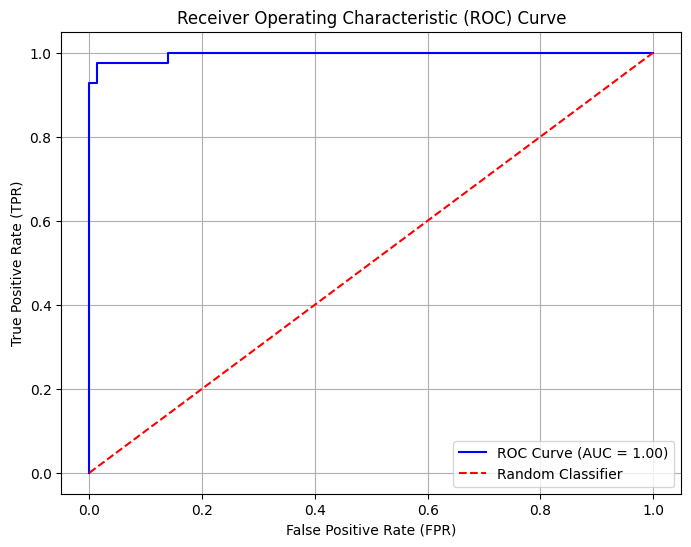

In [55]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curve
# y_test: true binary labels (1 for malignant, 0 for benign)
# probab[:, 1]: probabilities of the positive class (malignant)
fpr, tpr, thresholds = roc_curve(y_test, probab[:, 1])

# Calculate AUC score
auc_score = roc_auc_score(y_test, probab[:, 1])

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

The ROC curve plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various threshold settings. The Area Under the Curve (AUC) is a measure of the ability of a classifier to distinguish between classes. A higher AUC value (closer to 1) indicates a better performing model. An AUC of 0.5 suggests a classifier that performs no better than random guessing.

1.At which threshold are the fewest malignant tumors missed

2.Which threshold provides the highest specificity

3.which thresould provide the best f1 score

4.is the threshold with the higest accuracu necessary the safest for tumor detection

5.which error is more seriousin this application : false postive or false nagative ?

6.If msssing a malignant tumour is very costly , should the threshold be increased or decreased ?